# Notebook 01 - Data Audit
## Compound Crisis Cascade: Kenya

**Purpose:**  
This notebook answers four questions:
1. What is the shape and structure of each dataset?
2. What is the temporal coverage - and where do datasets overlap in time?
3. What is the geographic coverage - and which counties appear across all datasets?
4. Where are the gaps, and how do we handle them transparently?

**Datasets:**
- `hdx_hapi_rainfall_ken.csv` - WFP rainfall and anomaly data
- `hdx_hapi_food_price_ken.csv` - WFP food market prices
- `hdx_hapi_conflict_event_ken.csv` - ACLED conflict events
- `hdx_hapi_food_security_ken.csv` - IPC food security phases
- `hdx_hapi_population_ken.csv` - UNFPA baseline population
- `hdx_hapi_poverty_rate_ken.csv` - Oxford OPHI poverty rates

**Source:** HDX Humanitarian API — https://data.humdata.org/dataset/hdx-hapi-ken  

## 0.0 Setup - Libraries and Configuration

In [1]:
# Standard library imports
import os
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Settings
warnings.filterwarnings('ignore')          # Suppress minor pandas warnings
pd.set_option('display.max_columns', 30)   # Show all columns in previews
pd.set_option('display.float_format', '{:.2f}'.format)  # Clean float display

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Project colour palette
# Consistent colours used across all notebooks
COLOURS = {
    'rainfall':     '#2166ac',   # Blue  — water/climate
    'food_price':   '#d6604d',   # Red   — price stress
    'conflict':     '#1a1a1a',   # Near-black — severity
    'food_security':'#f4a582',   # Salmon — hunger
    'poverty':      '#762a83',   # Purple — structural vulnerability
    'highlight':    '#fdae61',   # Amber  — callout
    'neutral':      '#878787',   # Grey   — background elements
}

print("Libraries loaded successfully.")
print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")

Libraries loaded successfully.
pandas  1.4.4
numpy   1.24.4


## 1. Load Datasets

In [ ]:
#build a folder path
RAW = os.path.join('..', 'data', 'raw')

In [3]:
# Load all six datasets
# parse_dates converts reference period columns from string to datetime,
# which is essential for time-series analysis.
DATE_COLS = ['reference_period_start', 'reference_period_end']

def load_dataset(name):
    return pd.read_csv(
        os.path.join(RAW, f'hdx_hapi_{name}_ken.csv'),
        parse_dates=DATE_COLS
    )

In [4]:
#load datasets
datasets = [
    'rainfall',
    'food_price',
    'conflict_event',
    'food_security',
    'population',
    'poverty_rate'
]

DATASETS = {name: load_dataset(name) for name in datasets}

In [5]:
DATASETS['food_security'].head()

,location_code,has_hrp,in_gho,provider_admin1_name,provider_admin2_name,admin1_code,admin1_name,admin2_code,admin2_name,admin_level,ipc_phase,ipc_type,population_in_phase,population_fraction_in_phase,reference_period_start,reference_period_end
0,KEN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,0,all,current,16617000,1.00,2025-07-01,2025-09-30
1,KEN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,0,3+,current,1760950,0.11,2025-07-01,2025-09-30
2,KEN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,0,1,current,8426900,0.51,2025-07-01,2025-09-30
3,KEN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,0,2,current,6429150,0.39,2025-07-01,2025-09-30
4,KEN,False,True,NaN,NaN,NaN,NaN,NaN,NaN,0,3,current,1581650,0.10,2025-07-01,2025-09-30


## 2. Dataset Shapes and Structure

We first confirm the row count, column count, and data types for each dataset.  
This helps catch truncated downloads and encoding issues.

In [6]:
# Summary table: rows, columns, date range 
summary_rows = []

for name, df in DATASETS.items():
    summary_rows.append({
        'Dataset':    name,
        'Rows':       f"{len(df):,}",
        'Columns':    len(df.columns),
        'Date Start': df['reference_period_start'].min().date(),
        'Date End':   df['reference_period_end'].max().date(),
        'Null Cells': df.isnull().sum().sum(),
    })

summary_df = pd.DataFrame(summary_rows)
print("Dataset Overview")
print(" ")
print(summary_df.to_string(index=False))

Dataset Overview
 
       Dataset   Rows  Columns Date Start   Date End  Null Cells
      rainfall 11,460       20 2022-01-01 2026-02-20       22188
    food_price 14,972       22 2017-01-15 2025-12-14       30166
conflict_event  1,050       15 1997-01-01 2026-02-28        6300
 food_security  4,830       16 2019-07-01 2026-01-31       15848
    population  3,168       17 2019-01-01 2019-12-31        9702
  poverty_rate     73       14 2008-01-01 2022-12-31          39


In [8]:
# Inspect each dataset individually
# Running .info() shows column names, non-null counts, and dtypes.
# This tells us immediately if date parsing worked and which columns are empty.

for name, df in DATASETS.items():
    print(f"\n{' '}")
    print(f" {name.upper()}")
    print(f"{' '}")
    df.info(verbose=True, show_counts=True)


 
 RAINFALL
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11460 entries, 0 to 11459
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   location_code               11460 non-null  object        
 1   has_hrp                     11460 non-null  bool          
 2   in_gho                      11460 non-null  bool          
 3   provider_admin1_name        11460 non-null  object        
 4   provider_admin2_name        7884 non-null   object        
 5   admin1_code                 11460 non-null  object        
 6   admin1_name                 11460 non-null  object        
 7   admin2_code                 7884 non-null   object        
 8   admin2_name                 7884 non-null   object        
 9   admin_level                 11460 non-null  int64         
 10  provider_admin1_code        3576 non-null   float64       
 11  provider_admin2_code        7884 non-nu

## 3. Null Value Audit

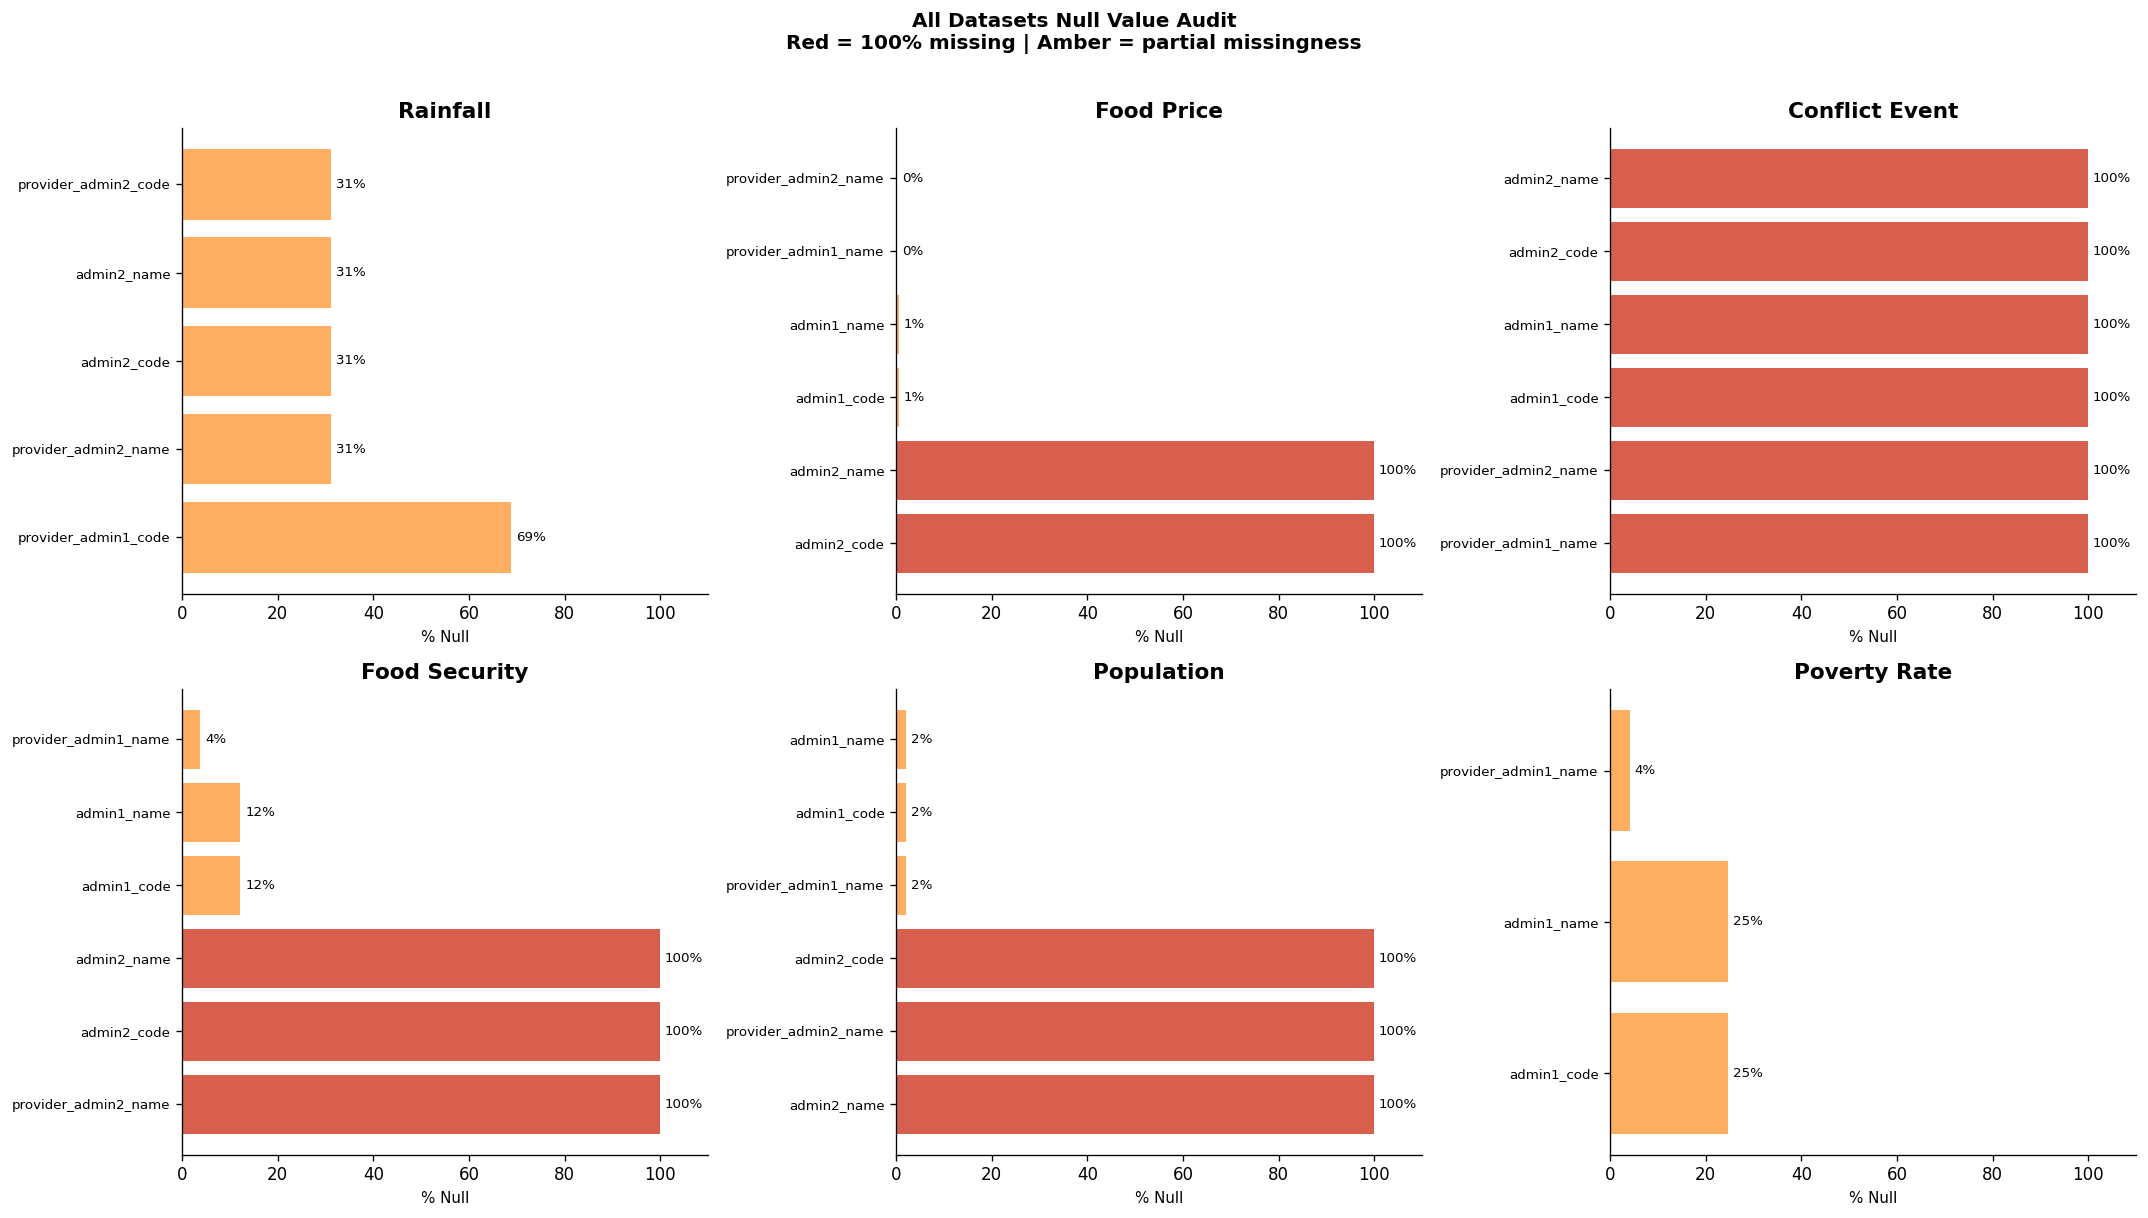

In [12]:
# Visualise missingness as a percentage per column per dataset using a heatmap
# Columns with 100% null are structurally missing hence not a cleaning problem.

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, df) in enumerate(DATASETS.items()):
    ax = axes[idx]

    # Calculate null percentage per column
    null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]  # Only show columns with any nulls

    if null_pct.empty:
        ax.text(0.5, 0.5, 'No nulls', ha='center', va='center',
                fontsize=14, color=COLOURS['neutral'])
        ax.set_title(name.replace('_', ' ').title(), fontweight='bold')
        ax.axis('off')
        continue

    # Colour bars: red if 100% null (structural), amber if partial
    bar_colours = [
        COLOURS['food_price'] if v == 100 else COLOURS['highlight']
        for v in null_pct.values
    ]

    bars = ax.barh(null_pct.index, null_pct.values, color=bar_colours)
    ax.set_xlim(0, 110)
    ax.set_xlabel('% Null', fontsize=9)
    ax.set_title(name.replace('_', ' ').title(), fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

    # Annotate each bar with its percentage
    for bar, val in zip(bars, null_pct.values):
        ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}%', va='center', fontsize=8)

plt.suptitle(
    'All Datasets Null Value Audit\n'
    'Red = 100% missing | Amber = partial missingness',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()

# create Output directories 
fig_dir = os.path.join('..', 'outputs', 'figures')
tbl_dir = os.path.join('..', 'outputs', 'tables')

# Create output folders if they do not exist
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(tbl_dir, exist_ok=True)

plt.savefig(
    os.path.join(fig_dir, '01_null_value_audit.png'),
    bbox_inches='tight', dpi=150
)
plt.show()